# Deepfake Video Detection — RetinaFace + Model Comparison

**Dataset:** Celeb-DF v2 (Kaggle) · **Target:** REAL / FAKE per video

**Pipeline:** video → evenly spaced frames → RetinaFace detection → eye alignment → 224×224 face → classifier → frame P(fake) → mean per video → REAL / FAKE

### Running on Kaggle (GPU)
1. Attach the **Celeb DF (v2)** dataset to this notebook (already visible in the Kaggle Input panel in the supplied setup).
2. Use a GPU accelerator.
3. Click **Run All**. The notebook auto-discovers the Celeb-DF v2 folder under `/kaggle/input` and writes generated artifacts to `/kaggle/working/Deepfake_Capstone`.
4. Existing saved outputs from the participant notebook are preserved in this file. New outputs are generated when their cells run.

| Sections | Owner |
|---|---|
| 1–3 Setup, data, face extraction | Participant 1 |
| 4–5 Training components, training | Participant 2 |
| 6–10 Comparison, robustness, calibration, explainability, demo | Participant 3 |
| 11 High vs Low Resolution 4-video check | Participant 4 |


## 1. Setup
Kaggle-compatible setup. No Google Drive or Colab mount is required.


In [1]:
!pip uninstall -y -q onnxruntime onnxruntime-gpu
!pip install -q timm==1.0.11 insightface==0.7.3 "onnxruntime-gpu<1.27" kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 25.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 32.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0

In [2]:
import functools
import gc
import io
import json
import math
import os
import random
import re
import shutil
import subprocess
import tarfile
import time
from dataclasses import asdict, dataclass, field
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from insightface.app import FaceAnalysis
from IPython.display import display
from PIL import Image, ImageFilter
from scipy.special import expit, logit
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    log_loss,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

cv2.setNumThreads(0)
pd.set_option("display.precision", 4)

In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


assert torch.cuda.is_available(), "Switch the runtime to a T4 GPU"
DEVICE = torch.device("cuda")
print(f"torch {torch.__version__} | timm {timm.__version__} | onnxruntime {ort.__version__} | {torch.cuda.get_device_name(0)}")

torch 2.11.0+cu128 | timm 1.0.11 | onnxruntime 1.26.0 | Tesla T4


In [4]:
SPLITS = ["train", "val", "holdout", "test"]
CLASS_NAMES = ("real", "fake")


@dataclass(frozen=True)
class Config:
    data_root: Path = Path("/kaggle/input")  # resolved automatically below
    work_root: Path = Path("/kaggle/working/Deepfake_Capstone/work")
    drive_root: Path = Path("/kaggle/working/Deepfake_Capstone/retinaface_models")  # kept as field name for compatibility
    kaggle_dataset: str = "reubensuju/celeb-df-v2"

    real_dirs: tuple = ("Celeb-real", "YouTube-real")
    fake_dirs: tuple = ("Celeb-synthesis",)
    test_list: str = "List_of_testing_videos.txt"
    val_frac: float = 0.15
    holdout_frac: float = 0.10
    split_seed: int = 42

    frames_real: int = 32
    frames_fake: int = 8
    frames_test: int = 16
    edge_trim: float = 0.05
    det_size: int = 640
    min_face_score: float = 0.5
    align_size: int = 256
    jpeg_quality: int = 95
    cache_shards: int = 12

    img_size: int = 224
    batch_size: int = 64
    num_workers: int = 2
    epochs: int = 8
    freeze_epochs: int = 1
    patience: int = 3
    lr_head: float = 1e-3
    warmup_frac: float = 0.05
    grad_clip: float = 1.0
    drop_rate: float = 0.3

    @property
    def video_dirs(self) -> tuple:
        return self.real_dirs + self.fake_dirs

    @property
    def cache_dir(self) -> Path:
        return self.work_root / "faces"

    @property
    def shard_dir(self) -> Path:
        return self.drive_root / "face_cache"

    @property
    def runs_dir(self) -> Path:
        return self.drive_root / "runs"

    @property
    def demo_dir(self) -> Path:
        return self.drive_root / "demo_videos"

    @property
    def manifest_path(self) -> Path:
        return self.drive_root / "videos.csv"

    def shard_path(self, index: int) -> Path:
        return self.shard_dir / f"shard_{index:02d}.tar"


CFG = Config()

### Models
| Key | Why it is in the comparison |
|---|---|
| `efficientnet_b0` | Baseline from the MTCNN run, retrained on RetinaFace crops |
| `resnet50` | Plain CNN reference point |
| `xception` | Standard FaceForensics++ deepfake baseline |
| `convnext_tiny` | Modern CNN with ImageNet-22k pretraining |
| `swin_tiny` | Windowed transformer that keeps local blending artefacts |
| `efficientnet_b4` | Larger EfficientNet (Noisy Student), common in top DFDC solutions |
| `clip_vit_b16` | CLIP features, which generalise well to unseen generators; only the last 4 blocks are fine-tuned |

BatchNorm CNNs keep the B0 recipe. ConvNeXt, Swin and CLIP use lower learning rates and weight decay 0.05. Every model gets the same crops, split, augmentation, 224 px input and epoch budget, and its own normalisation statistics from timm.

In [5]:
@dataclass(frozen=True)
class ModelSpec:
    timm_name: str
    lr_backbone: float
    weight_decay: float
    cam_layer: str
    drop_path_rate: float | None = 0.1
    trainable_blocks: int | None = None
    model_kwargs: dict = field(default_factory=dict)


MODELS = {
    "efficientnet_b0": ModelSpec("efficientnet_b0.ra_in1k", 2e-4, 1e-4, "bn2"),
    "resnet50": ModelSpec("resnet50.a1_in1k", 2e-4, 1e-4, "layer4"),
    "xception": ModelSpec("legacy_xception.tf_in1k", 2e-4, 1e-4, "act4", drop_path_rate=None),
    "convnext_tiny": ModelSpec("convnext_tiny.fb_in22k_ft_in1k", 1e-4, 0.05, "stages.3"),
    "swin_tiny": ModelSpec("swin_tiny_patch4_window7_224.ms_in22k_ft_in1k", 1e-4, 0.05, "layers.3"),
    "efficientnet_b4": ModelSpec("tf_efficientnet_b4.ns_jft_in1k", 2e-4, 1e-4, "bn2", drop_path_rate=0.2),
    "clip_vit_b16": ModelSpec(
        "vit_base_patch16_clip_224.openai", 2e-5, 0.05, "blocks.11.norm1",
        trainable_blocks=4, model_kwargs={"act_layer": "quick_gelu"},
    ),
}

pd.DataFrame({key: asdict(spec) for key, spec in MODELS.items()}).T.astype(str)

,timm_name,lr_backbone,weight_decay,cam_layer,drop_path_rate,trainable_blocks,model_kwargs
efficientnet_b0,efficientnet_b0.ra_in1k,0.0002,0.0001,bn2,0.1,None,{}
resnet50,resnet50.a1_in1k,0.0002,0.0001,layer4,0.1,None,{}
xception,legacy_xception.tf_in1k,0.0002,0.0001,act4,None,None,{}
convnext_tiny,convnext_tiny.fb_in22k_ft_in1k,0.0001,0.05,stages.3,0.1,None,{}
swin_tiny,swin_tiny_patch4_window7_224.ms_in22k_ft_in1k,0.0001,0.05,layers.3,0.1,None,{}
efficientnet_b4,tf_efficientnet_b4.ns_jft_in1k,0.0002,0.0001,bn2,0.2,None,{}
clip_vit_b16,vit_base_patch16_clip_224.openai,2e-05,0.05,blocks.11.norm1,0.1,4,{'act_layer': 'quick_gelu'}


In [6]:
# Kaggle environment: discover the attached Celeb-DF v2 dataset automatically.
def _looks_like_celeb_df(root: Path) -> bool:
    return all((root / name).is_dir() for name in ("Celeb-real", "YouTube-real", "Celeb-synthesis")) and (root / CFG.test_list).exists()

def find_celeb_df_root() -> Path:
    input_root = Path("/kaggle/input")
    candidates = [input_root]
    if input_root.exists():
        candidates += [p for p in input_root.rglob("*") if p.is_dir()]
    for p in candidates:
        if _looks_like_celeb_df(p):
            return p
    raise FileNotFoundError(
        "Celeb-DF v2 was not found under /kaggle/input. "
        "In Kaggle, use Add Input and attach the Celeb DF (v2) dataset, then Run All again."
    )

# Config is frozen, so update the discovered path safely.
object.__setattr__(CFG, "data_root", find_celeb_df_root())
for folder in (CFG.work_root, CFG.cache_dir, CFG.shard_dir, CFG.runs_dir, CFG.demo_dir):
    folder.mkdir(parents=True, exist_ok=True)
print(f"Dataset: {CFG.data_root}")
print(f"Artifacts: {CFG.drive_root}")


Mounted at /content/drive
Artifacts are saved under /content/drive/MyDrive/Deepfake_Capstone/retinaface_models


## 2. Data — Participant 1
The dataset (~9 GB) is downloaded only while the manifest, face cache or demo videos are missing on Drive.

**Split.** A fake video involves two identities, so identities that appear together are grouped into connected components and each component is assigned whole. That makes train / val / holdout identity-disjoint. The official 518-video test list is kept as a fourth split; by Celeb-DF's design it shares identities with train, so **holdout is the leak-free result**.

In [7]:
EXPECTED_VIDEOS = {"Celeb-real": 590, "YouTube-real": 300, "Celeb-synthesis": 5639}


def count_videos(folder: Path) -> int:
    return sum(1 for _ in folder.glob("*.mp4"))


def dataset_present() -> bool:
    return all(count_videos(CFG.data_root / folder) > 0 for folder in CFG.video_dirs)


def artifacts_on_drive() -> bool:
    shards_ready = all(CFG.shard_path(i).exists() for i in range(CFG.cache_shards))
    demo_ready = any(CFG.demo_dir.glob("*.mp4"))
    return CFG.manifest_path.exists() and shards_ready and demo_ready


def download_dataset() -> None:
    raise FileNotFoundError(
        "Celeb-DF v2 is not attached to this Kaggle notebook. "
        "Use Add Input → Celeb DF (v2). No Kaggle API key or Google Drive is required."
    )


In [8]:
if artifacts_on_drive():
    print("Manifest, face cache and demo videos found in Kaggle working storage. Skipping the dataset download.")
else:
    if not dataset_present():
        download_dataset()
    counts = {folder: count_videos(CFG.data_root / folder) for folder in CFG.video_dirs}
    assert counts == EXPECTED_VIDEOS, f"Unexpected video counts: {counts}"
    print(f"Dataset ready: {counts}")

Manifest, face cache and demo videos found on Drive. Skipping the dataset download.


In [9]:
RE_FAKE = re.compile(r"^id(\d+)_id(\d+)_\d+$")
RE_CELEB = re.compile(r"^id(\d+)_\d+$")
RE_YOUTUBE = re.compile(r"^(\d+)$")


def parse_identities(stem: str) -> tuple[str, str | None]:
    if match := RE_FAKE.match(stem):
        return f"id{match[1]}", f"id{match[2]}"
    if match := RE_CELEB.match(stem):
        return f"id{match[1]}", None
    if match := RE_YOUTUBE.match(stem):
        return f"yt_{match[1]}", None
    raise ValueError(f"Unrecognised video name: {stem}")


def scan_videos() -> pd.DataFrame:
    rows = []
    for folder in CFG.video_dirs:
        label = int(folder in CFG.fake_dirs)
        for path in sorted((CFG.data_root / folder).glob("*.mp4")):
            id_a, id_b = parse_identities(path.stem)
            rows.append({"rel_path": f"{folder}/{path.name}", "folder": folder, "stem": path.stem,
                         "label": label, "id_a": id_a, "id_b": id_b})
    return pd.DataFrame(rows)

In [10]:
def read_official_test_labels() -> pd.Series:
    rows = [line.split() for line in (CFG.data_root / CFG.test_list).read_text().splitlines()]
    return pd.Series({path: 1 - int(flag) for flag, path in (row for row in rows if len(row) == 2)})


def identity_components(videos: pd.DataFrame) -> pd.Series:
    parent = {}

    def find(identity: str) -> str:
        parent.setdefault(identity, identity)
        while parent[identity] != identity:
            parent[identity] = parent[parent[identity]]
            identity = parent[identity]
        return identity

    for id_a, id_b in zip(videos.id_a, videos.id_b):
        find(id_a)
        if isinstance(id_b, str):
            parent[find(id_b)] = find(id_a)
    return videos.id_a.map(find)

In [11]:
SPLIT_TARGETS = {"train": 1 - CFG.val_frac - CFG.holdout_frac, "val": CFG.val_frac, "holdout": CFG.holdout_frac}


def greedy_assign(sizes: pd.Series) -> dict:
    total, filled, assignment = sizes.sum(), dict.fromkeys(SPLIT_TARGETS, 0), {}
    for component, size in sizes.items():
        split = max(SPLIT_TARGETS, key=lambda s: SPLIT_TARGETS[s] * total - filled[s])
        assignment[component] = split
        filled[split] += size
    return assignment


def assign_splits(videos: pd.DataFrame) -> pd.Series:
    pool = videos[~videos.is_official_test]
    stats = pool.groupby("component").label.agg(n_fake="sum", n_videos="size")
    stats["n_real"] = stats.n_videos - stats.n_fake
    with_fakes = stats[stats.n_fake > 0].n_fake.sort_values(ascending=False, kind="stable")
    real_only = stats[stats.n_fake == 0].n_real.sort_values(ascending=False, kind="stable")
    assignment = {**greedy_assign(with_fakes), **greedy_assign(real_only)}
    return videos.component.map(assignment).where(~videos.is_official_test, "test")


def split_identities(videos: pd.DataFrame, split: str) -> set:
    subset = videos[videos.split == split]
    return set(subset.id_a) | set(subset.id_b.dropna())


def audit_leakage(videos: pd.DataFrame) -> None:
    for a, b in [("train", "val"), ("train", "holdout"), ("val", "holdout")]:
        shared = split_identities(videos, a) & split_identities(videos, b)
        assert not shared, f"{a} and {b} share identities: {sorted(shared)[:5]}"
    overlap = split_identities(videos, "test") & split_identities(videos, "train")
    print(f"train / val / holdout are identity-disjoint. "
          f"The official test shares {len(overlap)} identities with train (expected for Celeb-DF).")


def split_summary(videos: pd.DataFrame) -> pd.DataFrame:
    flags = videos.assign(real=videos.label == 0, fake=videos.label == 1, youtube_real=videos.folder == "YouTube-real")
    summary = flags.groupby("split")[["real", "fake", "youtube_real"]].sum().loc[SPLITS]
    summary["fake_per_real"] = summary.fake / summary.real
    return summary

In [12]:
def build_manifest() -> pd.DataFrame:
    videos = scan_videos()
    official = read_official_test_labels()
    videos["is_official_test"] = videos.rel_path.isin(official.index)
    assert videos.is_official_test.sum() == len(official), "Some official test videos are missing"
    assert (videos.set_index("rel_path").label[official.index] == official).all(), "Test-list labels disagree with folders"
    videos["component"] = identity_components(videos)
    videos["split"] = assign_splits(videos)
    return videos


def load_manifest() -> pd.DataFrame:
    if not CFG.manifest_path.exists():
        build_manifest().to_csv(CFG.manifest_path, index=False)
    return pd.read_csv(CFG.manifest_path)


def save_demo_videos(videos: pd.DataFrame) -> None:
    for rel_path in videos[videos.split == "holdout"].groupby("label").head(1).rel_path:
        target = CFG.demo_dir / Path(rel_path).name
        if not target.exists():
            shutil.copy(CFG.data_root / rel_path, target)

In [13]:
VIDEOS = load_manifest()
audit_leakage(VIDEOS)
if dataset_present():
    save_demo_videos(VIDEOS)
split_summary(VIDEOS)

train / val / holdout are identity-disjoint. The official test shares 36 identities with train (expected for Celeb-DF).


,real,fake,youtube_real,fake_per_real
split,,,,
train,495,3890,171,7.8586
val,112,705,35,6.2946
holdout,105,704,24,6.7048
test,178,340,70,1.9101


## 3. Face extraction — RetinaFace
Detector benchmark from the comparison notebook (10 videos × 15 frames, T4):

| Detector | Speed | Face yield |
|---|---|---|
| OpenCV Haar | 4.5 FPS | 99.3% |
| MTCNN | 15.4 FPS | 100% |
| **RetinaFace (buffalo_l)** | **50.2 FPS** | **100%** |
| YOLOv8n | 76.3 FPS | 100% |

RetinaFace is 3× faster than MTCNN at the same yield, and its five landmarks give a stable eye-aligned crop. YOLOv8 is faster but returns unaligned boxes. Detections below a score of 0.5 are discarded and the largest face in each frame is kept.

In [14]:
@functools.lru_cache(maxsize=1)
def get_detector() -> FaceAnalysis:
    if hasattr(ort, "preload_dlls"):
        ort.preload_dlls()
    detector = FaceAnalysis(name="buffalo_l", allowed_modules=["detection"],
                            providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
    detector.prepare(ctx_id=0, det_size=(CFG.det_size, CFG.det_size), det_thresh=CFG.min_face_score)
    providers = detector.det_model.session.get_providers()
    if "CUDAExecutionProvider" not in providers:
      raise RuntimeError(f"RetinaFace fell back to {providers}. Install an onnxruntime-gpu build for CUDA {torch.version.cuda}.")
    return detector

In [15]:
def frame_indices(n_total: int, count: int) -> np.ndarray:
    if n_total <= 0:
        return np.array([], dtype=int)
    first, last = int(n_total * CFG.edge_trim), int(n_total * (1 - CFG.edge_trim)) - 1
    if last <= first:
        first, last = 0, n_total - 1
    return np.linspace(first, last, min(count, last - first + 1)).astype(int)


def seek_frame(capture: cv2.VideoCapture, index: int) -> np.ndarray | None:
    capture.set(cv2.CAP_PROP_POS_FRAMES, int(index))
    ok, frame = capture.read()
    return frame if ok else None


def scan_frames(capture: cv2.VideoCapture, wanted: set[int]) -> list[np.ndarray]:
    capture.set(cv2.CAP_PROP_POS_FRAMES, 0)
    frames, index = [], 0
    ok, frame = capture.read()
    while ok:
        if index in wanted:
            frames.append(frame)
        index += 1
        ok, frame = capture.read()
    return frames


def read_frames(path: Path, count: int) -> list[np.ndarray]:
    capture = cv2.VideoCapture(str(path))
    wanted = frame_indices(int(capture.get(cv2.CAP_PROP_FRAME_COUNT)), count)
    frames = [frame for frame in (seek_frame(capture, i) for i in wanted) if frame is not None]
    if len(frames) < max(1, len(wanted) // 2):
        frames = scan_frames(capture, set(wanted.tolist()))
    capture.release()
    return frames

In [16]:
EYE_MARGIN_X = 0.35
EYE_LINE_Y = 0.35


def align_face(image: np.ndarray, landmarks: np.ndarray, size: int) -> np.ndarray | None:
    left_eye, right_eye = landmarks[0], landmarks[1]
    dx, dy = (right_eye - left_eye).tolist()
    distance = math.hypot(dx, dy)
    if distance < 1e-3:
        return None
    center = tuple(((left_eye + right_eye) / 2).tolist())
    scale = (1 - 2 * EYE_MARGIN_X) * size / distance
    matrix = cv2.getRotationMatrix2D(center, math.degrees(math.atan2(dy, dx)), scale)
    matrix[0, 2] += size * 0.5 - center[0]
    matrix[1, 2] += size * EYE_LINE_Y - center[1]
    return cv2.warpAffine(image, matrix, (size, size), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)


def largest_face(faces: list):
    return max(faces, key=lambda face: (face.bbox[2] - face.bbox[0]) * (face.bbox[3] - face.bbox[1]), default=None)


def extract_faces(path: Path, count: int) -> list[np.ndarray]:
    crops = []
    for frame in read_frames(path, count):
        face = largest_face(get_detector().get(frame))
        crop = None if face is None else align_face(frame, face.kps, CFG.align_size)
        if crop is not None:
            crops.append(crop)
    return crops

In [17]:
def show_images(images: list[np.ndarray], title: str) -> None:
    fig, axes = plt.subplots(1, len(images), figsize=(2 * len(images), 2.4), squeeze=False)
    for ax, image in zip(axes[0], images):
        ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.axis("off")
    fig.suptitle(title)
    plt.show()


if dataset_present():
    for row in VIDEOS.groupby("label").head(1).itertuples():
        crops = extract_faces(CFG.data_root / row.rel_path, 8)
        assert crops, f"No face found in {row.rel_path}"
        show_images(crops, f"{row.rel_path}: {len(crops)}/8 faces")

### Face cache
Crops are cached once at 256 px (JPEG q95) and shared by every model. Real videos give 32 frames, fake videos 8 and test videos 16, which balances the classes at extraction time. Each finished shard is copied to Kaggle working storage, so later sessions only unpack the shards (a few minutes) instead of re-running detection.

In [18]:
def frames_for(row) -> int:
    if row.split == "test":
        return CFG.frames_test
    return CFG.frames_fake if row.label else CFG.frames_real


def crop_name(row, index: int) -> str:
    return f"{row.split}/{CLASS_NAMES[row.label]}/{row.stem}_f{index:03d}.jpg"


def shard_videos(videos: pd.DataFrame, index: int) -> pd.DataFrame:
    shuffled = videos.sample(frac=1.0, random_state=CFG.split_seed)
    return shuffled.iloc[index::CFG.cache_shards]


def build_shard(videos: pd.DataFrame, index: int) -> None:
    shard, names = shard_videos(videos, index), []
    for row in tqdm(shard.itertuples(), total=len(shard), desc=f"Shard {index + 1}/{CFG.cache_shards}"):
        for j, crop in enumerate(extract_faces(CFG.data_root / row.rel_path, frames_for(row))):
            names.append(crop_name(row, j))
            cv2.imwrite(str(CFG.cache_dir / names[-1]), crop, [cv2.IMWRITE_JPEG_QUALITY, CFG.jpeg_quality])
    write_shard(names, index)

In [19]:
def write_shard(names: list[str], index: int) -> None:
    local = CFG.work_root / CFG.shard_path(index).name
    with tarfile.open(local, "w") as tar:
        for name in names:
            tar.add(CFG.cache_dir / name, arcname=name)
    staged = CFG.shard_path(index).with_suffix(".partial")
    shutil.copy(local, staged)
    staged.replace(CFG.shard_path(index))
    local.unlink()
    (CFG.cache_dir / f".{CFG.shard_path(index).stem}").touch()


def restore_shards() -> None:
    for path in sorted(CFG.shard_dir.glob("shard_*.tar")):
        marker = CFG.cache_dir / f".{path.stem}"
        if not marker.exists():
            with tarfile.open(path) as tar:
                tar.extractall(CFG.cache_dir, filter="data")
            marker.touch()


def ensure_face_cache(videos: pd.DataFrame) -> None:
    for split in SPLITS:
        for name in CLASS_NAMES:
            (CFG.cache_dir / split / name).mkdir(parents=True, exist_ok=True)
    restore_shards()
    for index in range(CFG.cache_shards):
        if not CFG.shard_path(index).exists():
            build_shard(videos, index)

In [20]:
ensure_face_cache(VIDEOS)

In [21]:
def index_face_cache(videos: pd.DataFrame) -> pd.DataFrame:
    paths = sorted(CFG.cache_dir.glob("*/*/*.jpg"))
    frames = pd.DataFrame({
        "path": [str(p) for p in paths],
        "stem": [p.stem.rsplit("_f", 1)[0] for p in paths],
        "folder_split": [p.parent.parent.name for p in paths],
    })
    frames = frames.merge(videos[["stem", "label", "split"]], on="stem", how="left", validate="many_to_one")
    assert frames.label.notna().all(), "The cache contains crops without a source video"
    assert (frames.folder_split == frames.split).all(), "Cache folders disagree with the manifest"
    return frames.drop(columns="folder_split").astype({"label": int})


FRAMES = index_face_cache(VIDEOS)
SPLIT_FRAMES = {split: FRAMES[FRAMES.split == split].reset_index(drop=True) for split in SPLITS}
print(f"{len(FRAMES):,} face crops | {len(set(VIDEOS.stem) - set(FRAMES.stem))} videos without a detected face")
FRAMES.groupby(["split", "label"]).size().unstack().rename(columns=dict(enumerate(CLASS_NAMES))).loc[SPLITS]

73,429 face crops | 0 videos without a detected face


label,real,fake
split,,
train,15805,31120
val,3584,5640
holdout,3360,5632
test,2848,5440


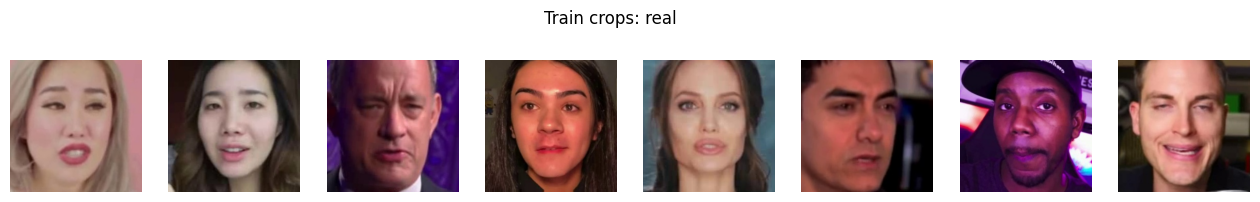

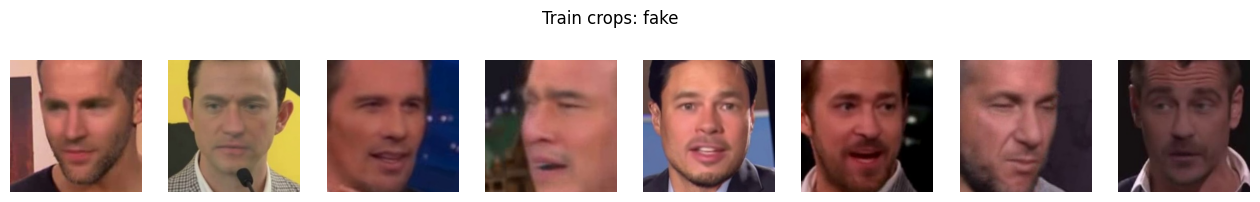

In [22]:
samples = SPLIT_FRAMES["train"].groupby("label").sample(8, random_state=CFG.split_seed)
for label, group in samples.groupby("label"):
    show_images([cv2.imread(path) for path in group.path], f"Train crops: {CLASS_NAMES[label]}")

## 4. Training components — Participant 2
- Frame classifier with one logit and `BCEWithLogitsLoss(pos_weight = real / fake)` on the training frames.
- Epoch 0 trains only the zero-initialised head; later epochs fine-tune the backbone (CLIP: last 4 blocks).
- AdamW with separate head / backbone learning rates and no decay on norms and biases, 5% warmup then cosine, fp16 autocast, gradient clipping.
- The best epoch is chosen on validation frame AUC with early stopping. The decision threshold is picked on validation (Youden's J) and reused unchanged for holdout and test.

In [23]:
def jpeg_compress(image: Image.Image, quality: int) -> Image.Image:
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG", quality=quality)
    return Image.open(buffer).convert("RGB")


class RandomJPEG:
    def __init__(self, quality: tuple[int, int] = (40, 95), p: float = 0.5):
        self.quality, self.p = quality, p

    def __call__(self, image: Image.Image) -> Image.Image:
        if random.random() > self.p:
            return image
        return jpeg_compress(image, random.randint(*self.quality))


def build_transforms(model: nn.Module) -> tuple[transforms.Compose, transforms.Compose]:
    data_cfg = timm.data.resolve_model_data_config(model)
    normalize = transforms.Normalize(data_cfg["mean"], data_cfg["std"])
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(CFG.img_size, scale=(0.8, 1.0), ratio=(0.95, 1.05)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
        RandomJPEG(),
        transforms.RandomApply([transforms.GaussianBlur(3, sigma=(0.1, 1.2))], p=0.1),
        transforms.ToTensor(),
        normalize,
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((CFG.img_size, CFG.img_size)),
        transforms.ToTensor(),
        normalize,
    ])
    return train_tf, eval_tf

In [24]:
class FaceDataset(Dataset):
    def __init__(self, frames: pd.DataFrame, transform):
        self.paths = frames.path.to_numpy()
        self.labels = frames.label.to_numpy(dtype=np.float32)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int):
        image = cv2.cvtColor(cv2.imread(self.paths[index]), cv2.COLOR_BGR2RGB)
        return self.transform(Image.fromarray(image)), self.labels[index]


def make_loader(frames: pd.DataFrame, transform, train: bool = False) -> DataLoader:
    return DataLoader(
        FaceDataset(frames, transform),
        batch_size=CFG.batch_size,
        shuffle=train,
        drop_last=train,
        num_workers=CFG.num_workers,
        pin_memory=True,
        persistent_workers=CFG.num_workers > 0,
    )


train_labels = SPLIT_FRAMES["train"].label
POS_WEIGHT = float((train_labels == 0).sum() / (train_labels == 1).sum())
print(f"pos_weight = {POS_WEIGHT:.3f}")

pos_weight = 0.508


In [25]:
def build_model(spec: ModelSpec, pretrained: bool = True) -> nn.Module:
    model = timm.create_model(
        spec.timm_name,
        pretrained=pretrained,
        num_classes=1,
        drop_rate=CFG.drop_rate,
        drop_path_rate=spec.drop_path_rate,
        **spec.model_kwargs,
    )
    head = model.get_classifier()
    nn.init.zeros_(head.weight)
    nn.init.zeros_(head.bias)
    return model.to(DEVICE)


def locked_prefixes(model: nn.Module, spec: ModelSpec) -> tuple:
    if spec.trainable_blocks is None:
        return ()
    n_locked = len(model.blocks) - spec.trainable_blocks
    return ("patch_embed", "cls_token", "pos_embed", "norm_pre", *(f"blocks.{i}." for i in range(n_locked)))


def set_phase(model: nn.Module, spec: ModelSpec, warmup: bool) -> int:
    head_ids = {id(p) for p in model.get_classifier().parameters()}
    locked = locked_prefixes(model, spec)
    for name, param in model.named_parameters():
        param.requires_grad = id(param) in head_ids or (not warmup and not name.startswith(locked))
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [26]:
def build_optimizer(model: nn.Module, spec: ModelSpec) -> torch.optim.AdamW:
    head_ids = {id(p) for p in model.get_classifier().parameters()}
    groups = {}
    for param in model.parameters():
        lr = CFG.lr_head if id(param) in head_ids else spec.lr_backbone
        weight_decay = 0.0 if param.ndim <= 1 else spec.weight_decay
        groups.setdefault((lr, weight_decay), []).append(param)
    return torch.optim.AdamW([{"params": params, "lr": lr, "weight_decay": wd} for (lr, wd), params in groups.items()])


def build_scheduler(optimizer: torch.optim.Optimizer, steps_per_epoch: int) -> torch.optim.lr_scheduler.LambdaLR:
    total = steps_per_epoch * CFG.epochs
    warmup = max(1, int(CFG.warmup_frac * total))

    def lr_factor(step: int) -> float:
        if step < warmup:
            return step / warmup
        progress = min(1.0, (step - warmup) / max(1, total - warmup))
        return 0.5 * (1 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_factor)

In [27]:
def equal_error_rate(y_true, y_prob) -> float:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return (fpr[i] + fnr[i]) / 2


def youden_threshold(y_true, y_prob) -> float:
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return float(thresholds[np.argmax(tpr - fpr)])


def classification_metrics(y_true, y_prob, threshold: float) -> dict:
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    scores = {
        "auc": roc_auc_score(y_true, y_prob),
        "ap": average_precision_score(y_true, y_prob),
        "eer": equal_error_rate(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall": recall,
        "specificity": tn / max(tn + fp, 1),
        "f1": f1,
    }
    counts = {"tn": tn, "fp": fp, "fn": fn, "tp": tp}
    return {**{k: float(v) for k, v in scores.items()}, **{k: int(v) for k, v in counts.items()}}


def prefixed(metrics: dict, prefix: str) -> dict:
    return {f"{prefix}{name}": value for name, value in metrics.items()}


def video_scores(frames: pd.DataFrame) -> pd.DataFrame:
    return frames.groupby("stem", sort=False).agg(label=("label", "first"), prob=("prob", "mean")).reset_index()


def score_predictions(frames: pd.DataFrame, threshold: float) -> dict:
    videos = video_scores(frames)
    return {
        **prefixed(classification_metrics(frames.label, frames.prob, threshold), "frame_"),
        **prefixed(classification_metrics(videos.label, videos.prob, threshold), "video_"),
    }

In [28]:
def train_one_epoch(model, loader, optimizer, scheduler, scaler, criterion) -> float:
    model.train()
    total_loss, seen = 0.0, 0
    for images, labels in tqdm(loader, desc="train", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True).unsqueeze(1)
        with torch.autocast("cuda", dtype=torch.float16):
            loss = criterion(model(images), labels)
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item() * len(images)
        seen += len(images)
    return total_loss / seen


@torch.no_grad()
def predict(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    probs = []
    for images, _ in tqdm(loader, desc="predict", leave=False):
        with torch.autocast("cuda", dtype=torch.float16):
            logits = model(images.to(DEVICE, non_blocking=True))
        probs.append(torch.sigmoid(logits.float()).squeeze(1).cpu().numpy())
    return np.concatenate(probs)


@torch.no_grad()
def gpu_throughput(model: nn.Module, batches: int = 20) -> float:
    model.eval()
    images = torch.randn(CFG.batch_size, 3, CFG.img_size, CFG.img_size, device=DEVICE)
    with torch.autocast("cuda", dtype=torch.float16):
        for _ in range(3):
            model(images)
        torch.cuda.synchronize()
        start = time.time()
        for _ in range(batches):
            model(images)
        torch.cuda.synchronize()
    return batches * len(images) / (time.time() - start)

In [29]:
def run_dir(key: str, seed: int) -> Path:
    return CFG.runs_dir / f"{key}_s{seed}"


def atomic_save(obj, path: Path) -> None:
    staged = path.with_suffix(".partial")
    torch.save(obj, staged)
    staged.replace(path)


def free_gpu() -> None:
    gc.collect()
    torch.cuda.empty_cache()

In [30]:
@dataclass
class TrainState:
    epoch: int = -1
    best_auc: float = 0.0
    bad_epochs: int = 0
    history: list = field(default_factory=list)


def save_checkpoint(path: Path, parts: dict, state: TrainState) -> None:
    atomic_save({**{name: part.state_dict() for name, part in parts.items()}, "state": asdict(state)}, path)


def load_checkpoint(path: Path, parts: dict) -> TrainState:
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)
    for name, part in parts.items():
        part.load_state_dict(checkpoint[name])
    return TrainState(**checkpoint["state"])


def format_epoch(row: dict, improved: bool) -> str:
    return (f"  epoch {row['epoch']} {row['phase']:<6} | loss {row['train_loss']:.4f} | "
            f"val AUC {row['val_frame_auc']:.4f} (video {row['val_video_auc']:.4f}, EER {row['val_video_eer']:.4f}) | "
            f"{row['minutes']:.1f} min{'  *' if improved else ''}")

In [31]:
class Trainer:
    def __init__(self, key: str, seed: int):
        seed_everything(seed)
        self.key, self.spec, self.out = key, MODELS[key], run_dir(key, seed)
        self.out.mkdir(parents=True, exist_ok=True)
        self.model = build_model(self.spec)
        train_tf, eval_tf = build_transforms(self.model)
        self.train_loader = make_loader(SPLIT_FRAMES["train"], train_tf, train=True)
        self.val_loader = make_loader(SPLIT_FRAMES["val"], eval_tf)
        self.optimizer = build_optimizer(self.model, self.spec)
        self.scheduler = build_scheduler(self.optimizer, len(self.train_loader))
        self.scaler = torch.amp.GradScaler("cuda")
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=DEVICE))
        self.parts = {"model": self.model, "optimizer": self.optimizer, "scheduler": self.scheduler, "scaler": self.scaler}
        self.state = TrainState()

    @property
    def done(self) -> bool:
        return self.state.epoch + 1 >= CFG.epochs or self.state.bad_epochs >= CFG.patience

    def fit(self) -> None:
        last = self.out / "last.pt"
        if last.exists():
            self.state = load_checkpoint(last, self.parts)
            print(f"{self.key}: resuming after epoch {self.state.epoch}")
        total = sum(p.numel() for p in self.model.parameters()) / 1e6
        tuned = set_phase(self.model, self.spec, warmup=False) / 1e6
        print(f"{self.key}: {total:.1f}M params ({tuned:.1f}M fine-tuned), {len(self.train_loader)} steps/epoch")
        while not self.done:
            self.state.epoch += 1
            self._run_epoch()
            save_checkpoint(last, self.parts, self.state)
            pd.DataFrame(self.state.history).to_csv(self.out / "history.csv", index=False)

    def _run_epoch(self) -> None:
        start, warmup = time.time(), self.state.epoch < CFG.freeze_epochs
        set_phase(self.model, self.spec, warmup)
        train_loss = train_one_epoch(self.model, self.train_loader, self.optimizer, self.scheduler, self.scaler, self.criterion)
        val = score_predictions(SPLIT_FRAMES["val"].assign(prob=predict(self.model, self.val_loader)), threshold=0.5)
        improved = val["frame_auc"] > self.state.best_auc
        if improved:
            self.state.best_auc = val["frame_auc"]
            atomic_save(self.model.state_dict(), self.out / "best.pt")
        self.state.bad_epochs = 0 if improved else self.state.bad_epochs + 1
        self.state.history.append({
            "epoch": self.state.epoch,
            "phase": "warmup" if warmup else "full",
            "train_loss": train_loss,
            "val_frame_auc": val["frame_auc"],
            "val_video_auc": val["video_auc"],
            "val_video_eer": val["video_eer"],
            "minutes": (time.time() - start) / 60,
        })
        print(format_epoch(self.state.history[-1], improved))

In [32]:
def load_best(key: str, seed: int) -> tuple[nn.Module, transforms.Compose]:
    model = build_model(MODELS[key], pretrained=False)
    model.load_state_dict(torch.load(run_dir(key, seed) / "best.pt", map_location=DEVICE))
    return model.eval(), build_transforms(model)[1]


def evaluate_run(key: str, seed: int) -> dict:
    out = run_dir(key, seed)
    model, eval_tf = load_best(key, seed)
    predictions = {
        split: SPLIT_FRAMES[split].assign(prob=predict(model, make_loader(SPLIT_FRAMES[split], eval_tf)))
        for split in ("val", "holdout", "test")
    }
    threshold = youden_threshold(predictions["val"].label, predictions["val"].prob)
    history = pd.read_csv(out / "history.csv")
    metrics = {
        "model": key,
        "seed": seed,
        "timm_name": MODELS[key].timm_name,
        "params_m": sum(p.numel() for p in model.parameters()) / 1e6,
        "gpu_img_per_s": gpu_throughput(model),
        "best_epoch": int(history.loc[history.val_frame_auc.idxmax(), "epoch"]),
        "train_minutes": float(history.minutes.sum()),
        "threshold": threshold,
    }
    for split, frames in predictions.items():
        frames[["stem", "label", "prob"]].to_csv(out / f"preds_{split}.csv", index=False)
        metrics.update(prefixed(score_predictions(frames, threshold), f"{split}_"))
    (out / "metrics.json").write_text(json.dumps(metrics, indent=2))
    return metrics


def run_model(key: str, seed: int) -> None:
    if (run_dir(key, seed) / "metrics.json").exists():
        print(f"{key} (seed {seed}): finished earlier, skipping")
        return
    trainer = Trainer(key, seed)
    trainer.fit()
    del trainer
    free_gpu()
    metrics = evaluate_run(key, seed)
    (run_dir(key, seed) / "last.pt").unlink(missing_ok=True)
    free_gpu()
    print(f"{key}: holdout video AUC {metrics['holdout_video_auc']:.4f} | test video AUC {metrics['test_video_auc']:.4f}\n")

## 5. Train all models
Each run takes roughly 45–90 minutes on a T4, lightest first. Set `RUN_ONLY` to split the models across team members. To repeat the top models with other seeds (for mean ± std), change `SEED` and list only those models.

In [33]:
SEED = 42
RUN_ONLY = list(MODELS)

for key in RUN_ONLY:
    run_model(key, SEED)

efficientnet_b0 (seed 42): finished earlier, skipping
resnet50 (seed 42): finished earlier, skipping
xception (seed 42): finished earlier, skipping
convnext_tiny (seed 42): finished earlier, skipping
swin_tiny (seed 42): finished earlier, skipping
efficientnet_b4 (seed 42): finished earlier, skipping


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  599MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

clip_vit_b16: resuming after epoch 2
clip_vit_b16: 85.8M params (28.4M fine-tuned), 733 steps/epoch


train:   0%|          | 0/733 [00:00<?, ?it/s]

...

  epoch 7 full   | loss 0.0542 | val AUC 0.9885 (video 0.9955, EER 0.0349) | 6.3 min


predict:   0%|          | 0/145 [00:00<?, ?it/s]

predict:   0%|          | 0/141 [00:00<?, ?it/s]

predict:   0%|          | 0/130 [00:00<?, ?it/s]

clip_vit_b16: holdout video AUC 0.9873 | test video AUC 0.9955



## 6. Comparison — Participant 3
Holdout is identity-disjoint from training and is the primary result. The official test shares identities with train. The 95% interval is a stratified bootstrap over holdout videos, so gaps smaller than the interval are noise.

In [34]:
def load_results() -> pd.DataFrame:
    rows = [json.loads(path.read_text()) for path in sorted(CFG.runs_dir.glob("*/metrics.json"))]
    assert rows, "No finished runs yet. Train at least one model in section 5."
    order = {key: i for i, key in enumerate(MODELS)}
    return pd.DataFrame(rows).sort_values(["model", "seed"], key=lambda s: s.map(order) if s.name == "model" else s)


def load_predictions(key: str, seed: int, split: str) -> pd.DataFrame:
    return pd.read_csv(run_dir(key, seed) / f"preds_{split}.csv")


def bootstrap_auc_ci(videos: pd.DataFrame, n_boot: int = 1000, seed: int = 0) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    real = videos.prob[videos.label == 0].to_numpy()
    fake = videos.prob[videos.label == 1].to_numpy()
    targets = np.r_[np.zeros(len(real)), np.ones(len(fake))]
    aucs = [roc_auc_score(targets, np.r_[rng.choice(real, len(real)), rng.choice(fake, len(fake))]) for _ in range(n_boot)]
    low, high = np.percentile(aucs, [2.5, 97.5])
    return float(low), float(high)

In [35]:
RESULTS = load_results()
intervals = [bootstrap_auc_ci(video_scores(load_predictions(r.model, r.seed, "holdout"))) for r in RESULTS.itertuples()]
RESULTS["holdout_ci_low"], RESULTS["holdout_ci_high"] = zip(*intervals)
PRIMARY = RESULTS[RESULTS.seed == SEED].reset_index(drop=True)

SUMMARY_COLUMNS = {
    "params_m": "Params (M)",
    "gpu_img_per_s": "GPU img/s",
    "train_minutes": "Train min",
    "holdout_frame_auc": "Holdout frame AUC",
    "holdout_video_auc": "Holdout video AUC",
    "holdout_ci_low": "CI low",
    "holdout_ci_high": "CI high",
    "holdout_video_eer": "Holdout video EER",
    "holdout_video_f1": "Holdout video F1",
    "test_video_auc": "Test video AUC",
    "test_video_f1": "Test video F1",
}
SUMMARY = (
    RESULTS.groupby("model", sort=False)[list(SUMMARY_COLUMNS)].mean()
    .assign(seeds=RESULTS.groupby("model", sort=False).size())
    .rename(columns=SUMMARY_COLUMNS)
    .sort_values(["Holdout video AUC", "Holdout video EER"], ascending=[False, True])
)
SUMMARY

,Params (M),GPU img/s,Train min,Holdout frame AUC,Holdout video AUC,CI low,CI high,Holdout video EER,Holdout video F1,Test video AUC,Test video F1,seeds
model,,,,,,,,,,,,
convnext_tiny,27.8209,575.4029,48.8136,0.9966,0.9999,0.9997,1.0000,0.0083,0.9895,0.9998,0.9537,1
efficientnet_b4,17.5504,516.6568,53.2193,0.9921,0.9990,0.9978,0.9999,0.0112,0.9881,0.9991,0.9605,1
swin_tiny,27.5201,461.9475,50.2059,0.9934,0.9988,0.9975,0.9997,0.0216,0.9894,0.9988,0.9458,1
xception,20.8090,567.1694,51.0944,0.9904,0.9986,0.9970,0.9996,0.0119,0.9908,0.9992,0.9605,1
resnet50,23.5101,841.3956,46.9342,0.9891,0.9981,0.9963,0.9994,0.0104,0.9873,0.9969,0.9630,1
efficientnet_b0,4.0088,1439.5422,44.8325,0.9890,0.9981,0.9963,0.9993,0.0202,0.9867,0.9979,0.9366,1
clip_vit_b16,85.8002,317.7015,50.3781,0.9725,0.9873,0.9811,0.9927,0.0487,0.9669,0.9955,0.9506,1


In [36]:
if RESULTS.seed.nunique() > 1:
    display(RESULTS.groupby("model", sort=False)[["holdout_video_auc", "holdout_video_eer", "test_video_auc"]].agg(["mean", "std", "count"]))

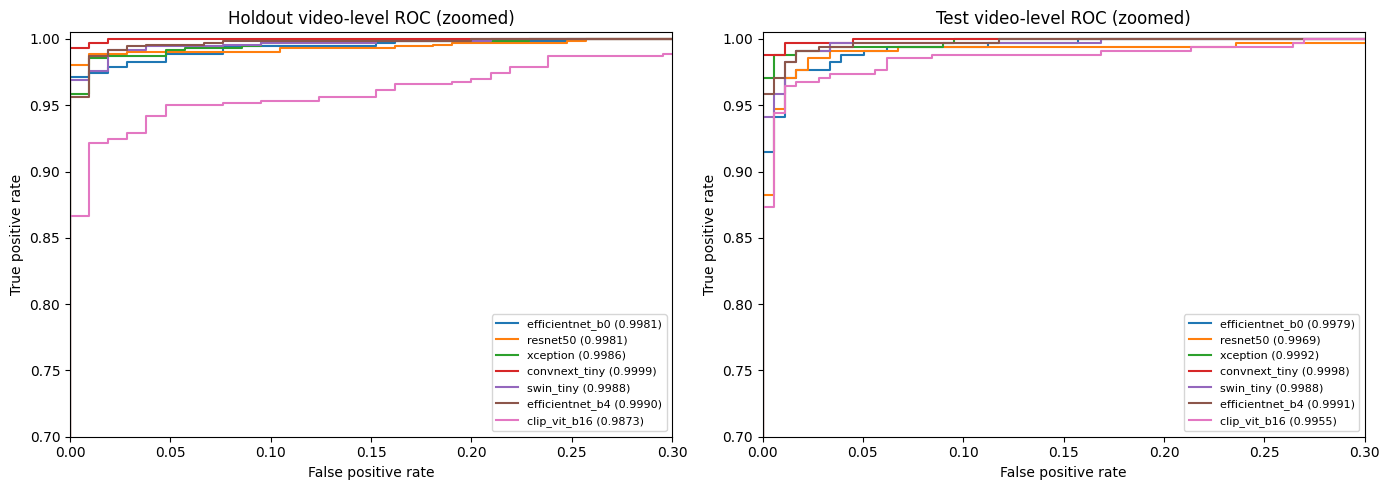

In [37]:
def axes_grid(count: int, ncols: int = 4, size: float = 3.2):
    nrows = math.ceil(count / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows), squeeze=False)
    for ax in axes.flat[count:]:
        ax.axis("off")
    return fig, axes.flat[:count]


def plot_roc(split: str, ax) -> None:
    for run in PRIMARY.itertuples():
        videos = video_scores(load_predictions(run.model, run.seed, split))
        fpr, tpr, _ = roc_curve(videos.label, videos.prob)
        ax.plot(fpr, tpr, label=f"{run.model} ({getattr(run, f'{split}_video_auc'):.4f})")
    ax.set(title=f"{split.title()} video-level ROC (zoomed)", xlabel="False positive rate",
           ylabel="True positive rate", xlim=(0, 0.3), ylim=(0.7, 1.005))
    ax.legend(fontsize=8, loc="lower right")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for split, ax in zip(("holdout", "test"), axes):
    plot_roc(split, ax)
plt.tight_layout()
plt.show()

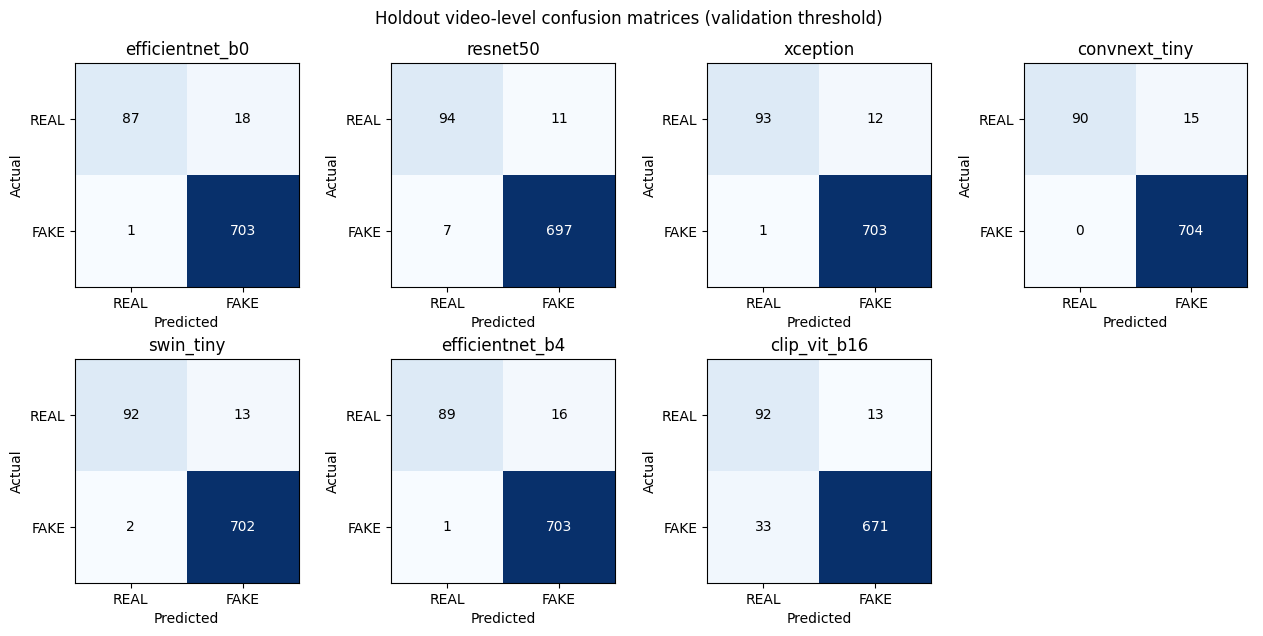

In [38]:
fig, axes = axes_grid(len(PRIMARY))
for ax, run in zip(axes, PRIMARY.itertuples()):
    matrix = np.array([[run.holdout_video_tn, run.holdout_video_fp], [run.holdout_video_fn, run.holdout_video_tp]])
    ax.imshow(matrix, cmap="Blues")
    for (i, j), value in np.ndenumerate(matrix):
        ax.text(j, i, value, ha="center", va="center", color="white" if value > matrix.max() / 2 else "black")
    ax.set(title=run.model, xticks=[0, 1], yticks=[0, 1], xticklabels=["REAL", "FAKE"],
           yticklabels=["REAL", "FAKE"], xlabel="Predicted", ylabel="Actual")
fig.suptitle("Holdout video-level confusion matrices (validation threshold)")
plt.tight_layout()
plt.show()

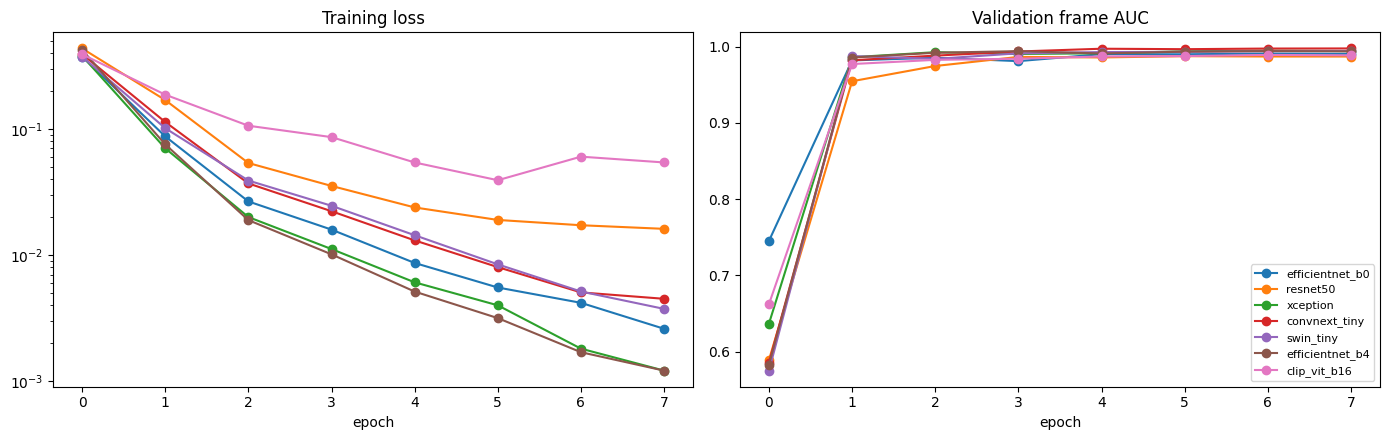

In [39]:
fig, (ax_loss, ax_auc) = plt.subplots(1, 2, figsize=(14, 4.5))
for run in PRIMARY.itertuples():
    history = pd.read_csv(run_dir(run.model, run.seed) / "history.csv")
    ax_loss.plot(history.epoch, history.train_loss, marker="o", label=run.model)
    ax_auc.plot(history.epoch, history.val_frame_auc, marker="o", label=run.model)
ax_loss.set(title="Training loss", xlabel="epoch", yscale="log")
ax_auc.set(title="Validation frame AUC", xlabel="epoch")
ax_auc.legend(fontsize=8)
plt.tight_layout()
plt.show()

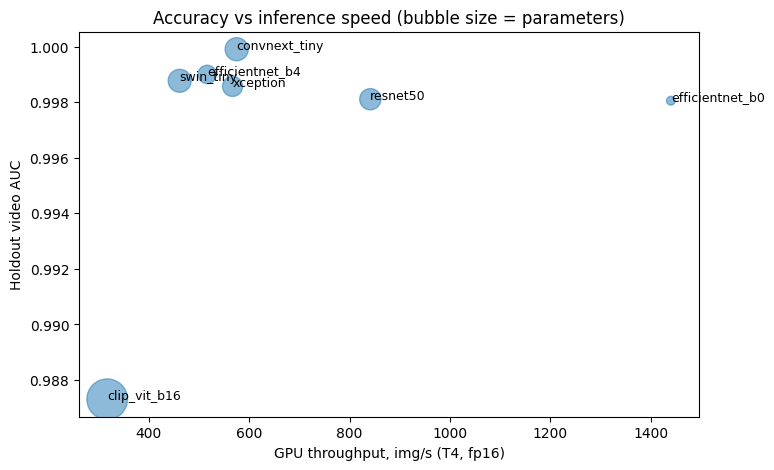

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(PRIMARY.gpu_img_per_s, PRIMARY.holdout_video_auc, s=PRIMARY.params_m * 10, alpha=0.5)
for run in PRIMARY.itertuples():
    ax.annotate(run.model, (run.gpu_img_per_s, run.holdout_video_auc), fontsize=9)
ax.set(title="Accuracy vs inference speed (bubble size = parameters)",
       xlabel="GPU throughput, img/s (T4, fp16)", ylabel="Holdout video AUC")
plt.show()

## 7. Robustness
Holdout faces (up to 8 per video) are scored again after JPEG re-compression, downscaling and blur, the degradations real uploads go through. `worst_drop` is the largest AUC loss against the clean score.

In [41]:
def downscale(image: Image.Image, factor: float = 0.5) -> Image.Image:
    width, height = image.size
    small = image.resize((int(width * factor), int(height * factor)), Image.Resampling.BILINEAR)
    return small.resize((width, height), Image.Resampling.BILINEAR)


def blur(image: Image.Image, radius: float = 1.5) -> Image.Image:
    return image.filter(ImageFilter.GaussianBlur(radius))


def identity(image: Image.Image) -> Image.Image:
    return image


PERTURBATIONS = {
    "clean": identity,
    "jpeg_q50": functools.partial(jpeg_compress, quality=50),
    "jpeg_q30": functools.partial(jpeg_compress, quality=30),
    "downscale_x0.5": downscale,
    "blur_r1.5": blur,
}
ROBUST_FRAMES = SPLIT_FRAMES["holdout"].groupby("stem").head(8).reset_index(drop=True)


def robustness(key: str, seed: int) -> pd.DataFrame:
    path = run_dir(key, seed) / "robustness.csv"
    if not path.exists():
        model, eval_tf = load_best(key, seed)
        rows = []
        for condition, perturb in PERTURBATIONS.items():
            loader = make_loader(ROBUST_FRAMES, transforms.Compose([perturb, eval_tf]))
            videos = video_scores(ROBUST_FRAMES.assign(prob=predict(model, loader)))
            rows.append({"model": key, "condition": condition, "video_auc": roc_auc_score(videos.label, videos.prob)})
        pd.DataFrame(rows).to_csv(path, index=False)
        del model
        free_gpu()
    return pd.read_csv(path)

In [42]:
ROBUSTNESS = pd.concat([robustness(run.model, run.seed) for run in PRIMARY.itertuples()])
robust_table = ROBUSTNESS.pivot(index="model", columns="condition", values="video_auc")[list(PERTURBATIONS)]
robust_table["worst_drop"] = robust_table["clean"] - robust_table.drop(columns="clean").min(axis=1)
robust_table.sort_values("worst_drop")

predict:   0%|          | 0/102 [00:00<?, ?it/s]

predict:   0%|          | 0/102 [00:00<?, ?it/s]

predict:   0%|          | 0/102 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78cdea5f02c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78cdea5f02c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

predict:   0%|          | 0/102 [00:00<?, ?it/s]

...

predict:   0%|          | 0/102 [00:00<?, ?it/s]

predict:   0%|          | 0/102 [00:00<?, ?it/s]

predict:   0%|          | 0/102 [00:00<?, ?it/s]

predict:   0%|          | 0/102 [00:00<?, ?it/s]

condition,clean,jpeg_q50,jpeg_q30,downscale_x0.5,blur_r1.5,worst_drop
model,,,,,,
convnext_tiny,0.9999,1.0000,0.9991,0.9990,0.9985,0.0014
xception,0.9988,0.9971,0.9972,0.9976,0.9968,0.0020
efficientnet_b0,0.9984,0.9958,0.9962,0.9966,0.9961,0.0026
resnet50,0.9990,0.9984,0.9987,0.9971,0.9961,0.0029
swin_tiny,0.9990,0.9984,0.9965,0.9968,0.9958,0.0032
efficientnet_b4,0.9991,0.9970,0.9930,0.9955,0.9944,0.0060
clip_vit_b16,0.9910,0.9881,0.9844,0.9776,0.9718,0.0192


## 8. Calibration
Raw probabilities are overconfident (the MTCNN B0 run needed a threshold of 0.02). One temperature per model, fitted on validation frames, rescales the logits without changing AUC. Lower log loss and ECE after scaling mean the probabilities can be read as confidence.

In [43]:
def to_logits(probs) -> np.ndarray:
    return logit(np.clip(np.asarray(probs, dtype=np.float64), 1e-6, 1 - 1e-6))


def fit_temperature(labels, probs) -> float:
    logits, grid = to_logits(probs), np.logspace(-1, 2, 300)
    losses = [log_loss(labels, expit(logits / t), labels=[0, 1]) for t in grid]
    return float(grid[int(np.argmin(losses))])


def expected_calibration_error(labels: np.ndarray, probs: np.ndarray, bins: int = 15) -> float:
    bin_ids = np.minimum((probs * bins).astype(int), bins - 1)
    return float(sum(
        (bin_ids == b).mean() * abs(labels[bin_ids == b].mean() - probs[bin_ids == b].mean())
        for b in np.unique(bin_ids)
    ))


def calibration_scores(videos: pd.DataFrame) -> tuple[float, float]:
    labels, probs = videos.label.to_numpy(), videos.prob.to_numpy()
    return log_loss(labels, probs, labels=[0, 1]), expected_calibration_error(labels, probs)


def calibration_report(key: str, seed: int) -> dict:
    val, holdout = load_predictions(key, seed, "val"), load_predictions(key, seed, "holdout")
    temperature = fit_temperature(val.label, val.prob)
    scaled = holdout.assign(prob=expit(to_logits(holdout.prob) / temperature))
    loss_before, ece_before = calibration_scores(video_scores(holdout))
    loss_after, ece_after = calibration_scores(video_scores(scaled))
    return {"model": key, "temperature": temperature, "log_loss_before": loss_before,
            "log_loss_after": loss_after, "ece_before": ece_before, "ece_after": ece_after}


pd.DataFrame([calibration_report(run.model, run.seed) for run in PRIMARY.itertuples()]).set_index("model")

,temperature,log_loss_before,log_loss_after,ece_before,ece_after
model,,,,,
efficientnet_b0,2.7849,0.1757,0.2075,0.1124,0.1529
resnet50,2.3691,0.2992,0.3200,0.1956,0.2328
xception,2.1600,0.1882,0.2011,0.1226,0.1412
convnext_tiny,2.8500,0.0654,0.0786,0.0498,0.0634
swin_tiny,3.4286,0.1839,0.1914,0.1098,0.1335
efficientnet_b4,2.4811,0.1755,0.2019,0.1178,0.1468
clip_vit_b16,3.1990,0.7097,0.5108,0.2606,0.2848


## 9. Explainability — Grad-CAM
One real and one fake holdout face through every model. The heatmap is taken from each model's last spatial layer (`cam_layer` in the registry); for CLIP the patch tokens of the last block are reshaped to a 14×14 grid.

In [44]:
def to_nchw(tensor: torch.Tensor, model: nn.Module) -> torch.Tensor:
    if tensor.ndim == 3:
        tokens = tensor[:, model.num_prefix_tokens:]
        side = math.isqrt(tokens.shape[1])
        return tokens.transpose(1, 2).reshape(len(tensor), -1, side, side)
    if getattr(model, "output_fmt", "NCHW") == "NHWC":
        return tensor.permute(0, 3, 1, 2)
    return tensor


def grad_cam(model: nn.Module, layer_name: str, image: torch.Tensor) -> tuple[np.ndarray, float]:
    captured = {}

    def hook(_module, _inputs, output):
        captured["activation"] = output
        output.register_hook(lambda grad: captured.update(gradient=grad))

    handle = model.get_submodule(layer_name).register_forward_hook(hook)
    model.zero_grad(set_to_none=True)
    score = model(image.unsqueeze(0).to(DEVICE)).squeeze()
    score.backward()
    handle.remove()

    activation = to_nchw(captured["activation"], model)
    gradient = to_nchw(captured["gradient"], model)
    cam = (gradient.mean(dim=(2, 3), keepdim=True) * activation).sum(dim=1, keepdim=True).relu()
    cam = F.interpolate(cam, size=(CFG.img_size, CFG.img_size), mode="bilinear", align_corners=False)[0, 0]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam.detach().cpu().numpy(), torch.sigmoid(score).item()

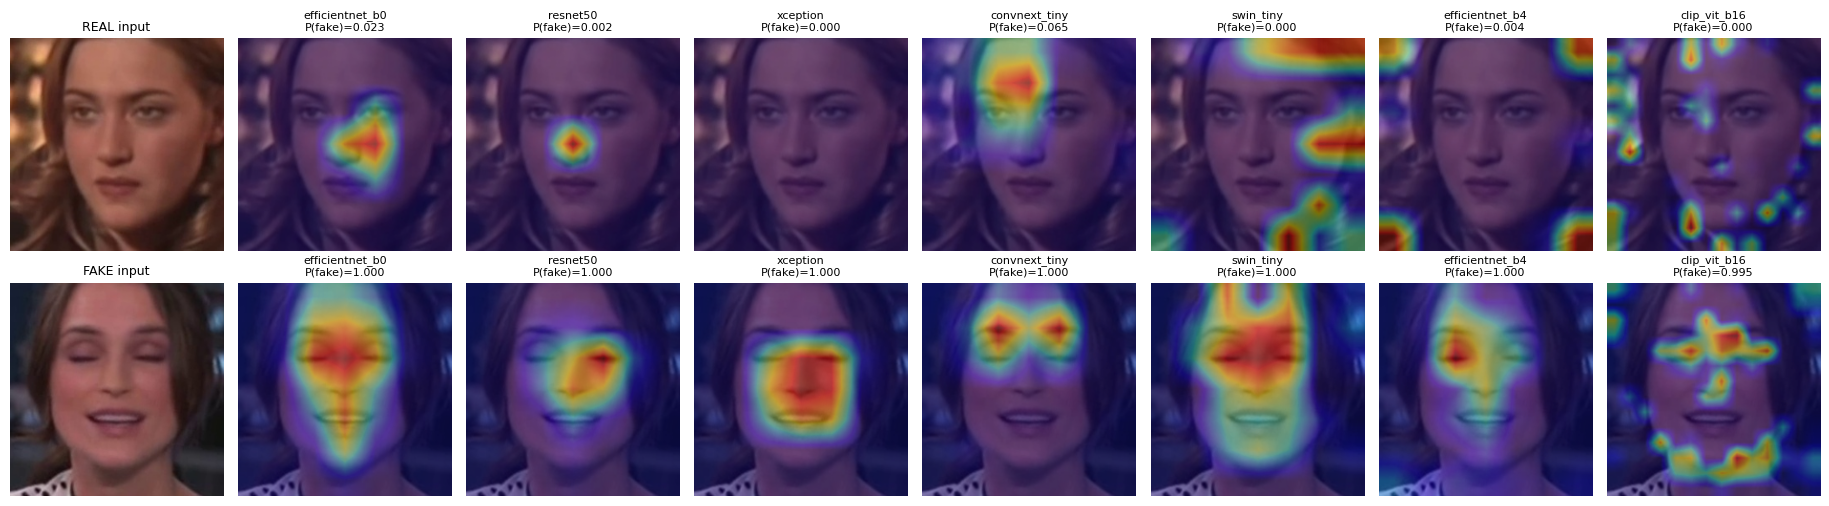

In [45]:
cam_frames = SPLIT_FRAMES["holdout"].groupby("label").sample(1, random_state=CFG.split_seed)
faces = [Image.open(path).convert("RGB") for path in cam_frames.path]
fig, axes = plt.subplots(len(faces), len(PRIMARY) + 1, figsize=(2.3 * (len(PRIMARY) + 1), 2.6 * len(faces)), squeeze=False)

for row, (face, label) in enumerate(zip(faces, cam_frames.label)):
    axes[row, 0].imshow(face.resize((CFG.img_size, CFG.img_size)))
    axes[row, 0].set_title(f"{CLASS_NAMES[label].upper()} input", fontsize=9)

for col, run in enumerate(PRIMARY.itertuples(), start=1):
    model, eval_tf = load_best(run.model, run.seed)
    for row, face in enumerate(faces):
        cam, p_fake = grad_cam(model, MODELS[run.model].cam_layer, eval_tf(face))
        axes[row, col].imshow(face.resize((CFG.img_size, CFG.img_size)))
        axes[row, col].imshow(cam, cmap="jet", alpha=0.4)
        axes[row, col].set_title(f"{run.model}\nP(fake)={p_fake:.3f}", fontsize=8)
    del model
    free_gpu()

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 10. End-to-end demo and export
The best model by holdout video AUC runs the full pipeline on the demo videos saved to Kaggle working storage: RetinaFace → alignment → classifier → mean P(fake) → REAL / FAKE at the validation threshold.

In [46]:
def predict_video(path: Path, model: nn.Module, eval_tf, threshold: float, count: int = 32) -> dict:
    crops = extract_faces(path, count)
    if not crops:
        return {"faces": 0, "p_fake": float("nan"), "prediction": "NO FACE"}
    batch = torch.stack([eval_tf(Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))) for crop in crops])
    with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
        p_fake = torch.sigmoid(model(batch.to(DEVICE)).float()).mean().item()
    return {"faces": len(crops), "p_fake": p_fake, "prediction": "FAKE" if p_fake >= threshold else "REAL"}


BEST_MODEL = SUMMARY.index[0]
best_model, best_tf = load_best(BEST_MODEL, SEED)
best_threshold = float(PRIMARY.set_index("model").loc[BEST_MODEL, "threshold"])
video_labels = VIDEOS.set_index("stem").label

demo_rows = []
for path in sorted(CFG.demo_dir.glob("*.mp4")):
    start = time.time()
    result = predict_video(path, best_model, best_tf, best_threshold)
    demo_rows.append({"video": path.name, "truth": CLASS_NAMES[video_labels[path.stem]].upper(),
                      **result, "seconds": time.time() - start})
print(f"Best model: {BEST_MODEL} | threshold {best_threshold:.4f}")
pd.DataFrame(demo_rows)

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 84232.93KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvid

,video,truth,faces,p_fake,prediction,seconds
0,id49_0000.mp4,REAL,32,2.5084e-05,REAL,18.0370
1,id49_id50_0000.mp4,FAKE,32,8.7174e-01,FAKE,1.6172


In [47]:
data_cfg = timm.data.resolve_model_data_config(best_model)
bundle = {
    "model_key": BEST_MODEL,
    "timm_name": MODELS[BEST_MODEL].timm_name,
    "model_kwargs": MODELS[BEST_MODEL].model_kwargs,
    "state_dict": best_model.state_dict(),
    "threshold": best_threshold,
    "img_size": CFG.img_size,
    "mean": data_cfg["mean"],
    "std": data_cfg["std"],
    "align_size": CFG.align_size,
    "min_face_score": CFG.min_face_score,
    "labels": {0: "REAL", 1: "FAKE"},
}
bundle_path = CFG.drive_root / f"deepfake_{BEST_MODEL}_final.pt"
torch.save(bundle, bundle_path)
SUMMARY.to_csv(CFG.drive_root / "model_comparison.csv")
print(f"Saved {bundle_path.name} and model_comparison.csv to {CFG.drive_root}")

Saved deepfake_convnext_tiny_final.pt and model_comparison.csv to /content/drive/MyDrive/Deepfake_Capstone/retinaface_models


## Requirement check
| Requirement | Where |
|---|---|
| Problem and target | REAL vs FAKE per video |
| Dataset | Celeb-DF v2, downloaded from Kaggle |
| Frame extraction | Evenly spaced frames, 5% trimmed at both ends |
| Face detection and alignment | RetinaFace (buffalo_l), 5-landmark eye alignment |
| Resize and normalise | 224 px, per-model timm mean / std |
| Split | Identity-disjoint train / val / holdout plus the official 518-video test |
| Augmentation | Crop, flip, colour, JPEG, blur |
| Class imbalance | Asymmetric frame sampling and `pos_weight` |
| Models | EfficientNet-B0, ResNet-50, Xception, ConvNeXt-T, Swin-T, EfficientNet-B4, CLIP ViT-B/16 |
| Video aggregation | Mean frame probability |
| Metrics | AUC, AP, EER, accuracy, precision, recall, specificity, F1, bootstrap CI |
| Robustness | JPEG, downscale and blur stress tests |
| Calibration | Temperature scaling, log loss, ECE |
| Explainability | Grad-CAM for every model |
| Inference speed | GPU throughput per model |
| Demo and export | End-to-end video prediction, saved inference bundle |

## 11. Participant 4 — High vs Low Resolution Video Check

This section is **additive only**: it does not change the earlier participants’ training, comparison, face extraction, Grad-CAM, robustness, or demo code/results.

**Goal:** evaluate exactly four videos with the already-selected best model:
- 1 REAL high-resolution video
- 1 FAKE high-resolution video
- 1 REAL low-resolution video
- 1 FAKE low-resolution video

The section automatically selects high/low-resolution examples from the available Celeb-DF videos (or accepts manual overrides), shows the aligned RetinaFace crops used by the classifier, and reports the final REAL/FAKE prediction and probability.

> Run this section **after Sections 1–10** in the same GPU runtime. Existing saved outputs above remain preserved in this notebook.


In [ ]:
# Participant 4 configuration and safety checks
from pathlib import Path
import math

# Optional: provide exact videos here. Leave as None to auto-select by native resolution.
# Paths may be absolute, or relative to CFG.data_root.
P4_VIDEO_OVERRIDES = {
    "REAL_HIGH": None,
    "FAKE_HIGH": None,
    "REAL_LOW": None,
    "FAKE_LOW": None,
}
P4_FACE_FRAMES_TO_SHOW = 6
P4_FRAMES_TO_SCORE = 32

_required = ["CFG", "VIDEOS", "CLASS_NAMES", "extract_faces", "load_best", "PRIMARY", "SUMMARY", "SEED"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "Run Sections 1–10 first. Missing required objects: " + ", ".join(_missing)
    )
if not torch.cuda.is_available():
    raise RuntimeError("A GPU runtime is required because the RetinaFace setup in this notebook uses CUDA.")

P4_DEVICE = torch.device("cuda")

def p4_resolve_path(value):
    if value is None:
        return None
    p = Path(value).expanduser()
    if p.exists():
        return p
    candidate = CFG.data_root / p
    if candidate.exists():
        return candidate
    raise FileNotFoundError(f"Video not found: {value}")

def p4_video_info(path: Path) -> dict:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        cap.release()
        raise RuntimeError(f"OpenCV could not open video: {path}")
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
    cap.release()
    if width <= 0 or height <= 0:
        raise RuntimeError(f"Could not read video resolution: {path}")
    return {"width": width, "height": height, "pixels": width * height, "frames_total": frames, "fps": fps}

def p4_label_for_path(path: Path) -> int:
    # Prefer the notebook manifest; fall back to Celeb-DF folder naming.
    matches = VIDEOS.loc[VIDEOS.stem.eq(path.stem), "label"]
    if len(matches):
        return int(matches.iloc[0])
    parent = path.parent.name.lower()
    if "synthesis" in parent or "fake" in parent:
        return 1
    if "real" in parent:
        return 0
    raise ValueError(f"Could not infer REAL/FAKE label for {path}")

print("Participant 4 preflight OK")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Dataset root: {CFG.data_root}")


In [ ]:
# Select exactly 4 videos: REAL/FAKE × HIGH/LOW native resolution
def p4_available_videos() -> pd.DataFrame:
    rows = []
    for row in VIDEOS.itertuples():
        path = CFG.data_root / row.rel_path
        if not path.exists():
            continue
        try:
            info = p4_video_info(path)
        except Exception:
            continue
        rows.append({"path": path, "video": path.name, "label": int(row.label), **info})
    if not rows:
        raise FileNotFoundError(
            f"No Celeb-DF videos were found under {CFG.data_root}. "
            "Restore/download the dataset as done in Section 2, then rerun this cell."
        )
    return pd.DataFrame(rows)

def p4_choose_videos() -> pd.DataFrame:
    available = p4_available_videos()
    chosen = []
    for label, label_name in [(0, "REAL"), (1, "FAKE")]:
        group = available[available.label.eq(label)].sort_values(["pixels", "video"])
        if group.empty:
            raise RuntimeError(f"No {label_name} videos are available.")
        for quality, default_row in [("LOW", group.iloc[0]), ("HIGH", group.iloc[-1])]:
            key = f"{label_name}_{quality}"
            override = p4_resolve_path(P4_VIDEO_OVERRIDES[key])
            if override is None:
                item = default_row.to_dict()
            else:
                actual_label = p4_label_for_path(override)
                if actual_label != label:
                    raise ValueError(f"{key} override has the wrong class: {override}")
                item = {"path": override, "video": override.name, "label": label, **p4_video_info(override)}
            item["case"] = key
            item["truth"] = label_name
            item["resolution_group"] = quality
            chosen.append(item)
    result = pd.DataFrame(chosen)
    order = ["REAL_HIGH", "FAKE_HIGH", "REAL_LOW", "FAKE_LOW"]
    result["_order"] = result.case.map({name: i for i, name in enumerate(order)})
    return result.sort_values("_order").drop(columns="_order").reset_index(drop=True)

P4_SELECTED = p4_choose_videos()
P4_SELECTED["resolution"] = P4_SELECTED.width.astype(str) + "×" + P4_SELECTED.height.astype(str)
display(P4_SELECTED[["case", "video", "truth", "resolution", "frames_total", "fps"]])


In [ ]:
# Load the same best model/threshold selected by the colleague's comparison section
P4_BEST_MODEL = SUMMARY.index[0]
P4_MODEL, P4_TF = load_best(P4_BEST_MODEL, SEED)
P4_MODEL = P4_MODEL.to(P4_DEVICE).eval()
P4_THRESHOLD = float(PRIMARY.set_index("model").loc[P4_BEST_MODEL, "threshold"])

def p4_predict_from_crops(crops):
    if not crops:
        return float("nan"), "NO FACE"
    tensors = [P4_TF(Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))) for crop in crops]
    batch = torch.stack(tensors).to(P4_DEVICE)
    amp_enabled = P4_DEVICE.type == "cuda"
    with torch.inference_mode():
        with torch.autocast(device_type=P4_DEVICE.type, dtype=torch.float16, enabled=amp_enabled):
            logits = P4_MODEL(batch).float().reshape(-1)
            p_fake = torch.sigmoid(logits).mean().item()
    return p_fake, ("FAKE" if p_fake >= P4_THRESHOLD else "REAL")

print(f"Using best model: {P4_BEST_MODEL}")
print(f"Validation threshold: {P4_THRESHOLD:.4f}")


In [ ]:
# Run the 4-video resolution experiment and SHOW the detected/aligned face frames
P4_RESULTS = []
P4_CROPS = {}

for row in P4_SELECTED.itertuples():
    path = Path(row.path)
    print(f"\n{row.case}: {path.name} | native resolution {row.width}×{row.height}")
    start = time.time()
    crops = extract_faces(path, P4_FRAMES_TO_SCORE)
    P4_CROPS[row.case] = crops
    p_fake, prediction = p4_predict_from_crops(crops)
    elapsed = time.time() - start

    if crops:
        n_show = min(P4_FACE_FRAMES_TO_SHOW, len(crops))
        show_images(crops[:n_show], f"{row.case} — aligned RetinaFace crops ({n_show} shown / {len(crops)} detected)")
    else:
        print("No usable face crops detected for this video.")

    P4_RESULTS.append({
        "case": row.case,
        "video": path.name,
        "truth": row.truth,
        "resolution": f"{row.width}×{row.height}",
        "faces_detected": len(crops),
        "p_fake": p_fake,
        "prediction": prediction,
        "correct": prediction == row.truth,
        "seconds": elapsed,
    })

P4_RESULTS = pd.DataFrame(P4_RESULTS)
display(P4_RESULTS)


In [ ]:
# Compact comparison for report / viva
P4_SUMMARY = P4_RESULTS[["case", "truth", "resolution", "faces_detected", "p_fake", "prediction", "correct"]].copy()
P4_SUMMARY["p_fake"] = P4_SUMMARY["p_fake"].round(4)
print("Participant 4 — High vs Low Resolution Comparison")
display(P4_SUMMARY)

valid = P4_RESULTS[P4_RESULTS.prediction.ne("NO FACE")].copy()
if len(valid):
    print(f"Accuracy on these 4 demonstration videos: {valid.correct.mean():.1%} ({int(valid.correct.sum())}/{len(valid)})")
else:
    print("No videos produced a usable prediction; inspect face detection and input videos.")

# Save only this participant's table; earlier participants' artifacts/outputs are untouched.
try:
    p4_out_dir = CFG.drive_root
    p4_out_dir.mkdir(parents=True, exist_ok=True)
    p4_csv = p4_out_dir / "participant4_resolution_4video_results.csv"
    P4_RESULTS.to_csv(p4_csv, index=False)
    print(f"Saved: {p4_csv}")
except Exception as exc:
    print(f"Result table displayed successfully; CSV save skipped: {exc}")


### Participant 4 interpretation

Use the table above to compare whether the selected model remains correct when the native video resolution is lower. The displayed aligned face crops are the actual face inputs extracted by RetinaFace for these four videos. A lower face count or a confidence shift on the low-resolution examples can be discussed as evidence that resolution affects the end-to-end pipeline.

**Important:** this is a four-video demonstration, not a statistically representative accuracy benchmark. The broader robustness experiment in Section 7 remains the stronger aggregate test.
